# Step 2: Feature Engineering — 14 Behavioral Features Across 5 Categories

This notebook constructs **20 candidate behavioral features** across 5 commercial domains from cleaned transaction data. A greedy Pearson correlation filter ($|r| > 0.85$) is applied to retain **14 non-redundant features**, followed by a preprocessing pipeline combining `QuantileTransformer`, `StandardScaler`, and $\pm 3\sigma$ outlier clipping.

The normalized feature matrix feeds into a **Two-Stage Clustering Pipeline**:
1. **Stage 1 (B2B Rule-based Filtering):** Identifies wholesale accounts based on raw feature thresholds (`SKU_HHI > 0.5`), isolating 179 B2B customers.
2. **Stage 2 (Retail K-Means++):** Applies K-Means++ ($k=4$) on the remaining retail population (3,741 customers).




## Objectives

1. **Feature Engineering:** Build 20 candidate behavioral features spanning 5 behavioral domains.
2. **Multicollinearity Reduction:** Apply greedy Pearson correlation thresholding ($|r| > 0.85$) to select 14 core features.
3. **Data Preprocessing Pipeline:** Transform features using `QuantileTransformer` (normal output distribution, 500 quantiles), `StandardScaler`, and $\pm 3\sigma$ Windsorization/clipping.
4. **B2B Identification:** Rule-based isolation of wholesale accounts via `SKU_HHI > 0.5` prior to main clustering.
5. **Feature Persistence:** Save scaled feature matrices for the total population and retail subset.

**Why Move Beyond RFM?** Traditional 3-dimensional RFM models fail to differentiate:
* High-return accounts (e.g., 25% invoice cancellation rates) vs. high-intent repeat buyers.
* Highly seasonal buyers vs. steady, year-round shoppers.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

from clustering_library import FeatureEngineer
from notebook_io import wpath, rpath   # manual runs write to data/_sandbox, never canonical
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Cleaned Data

In [2]:
# Read 01's cleaned data from the sandbox if a manual run produced it, else canonical.
data_path     = rpath('processed/cleaned_uk_data.csv')
raw_data_path = '../data/raw/online_retail.xlsx'

fe = FeatureEngineer(data_path, raw_data_path=raw_data_path)
df = fe.load_data()
print(f"Dataset: {df.shape[0]:,} transactions | {df['CustomerID'].nunique():,} customers")
print(f"Date range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
df.head()

Dataset: 354,321 transactions | 3,920 customers
Date range: 2010-12-01 → 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,HourOfDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2,8


## Feature Candidate Groups (20 Candidates $\rightarrow$ 14 Retained)

The 20 engineered candidate features span 5 commercial domains. Features marked with **(Dropped)** were removed via greedy Pearson correlation filtering ($|r| > 0.85$) to eliminate feature redundancy and collinearity.

| Domain | Feature | Mathematical Formulation / Definition | Status |
| :--- | :--- | :--- | :---: |
| **1. Purchase Cadence** | `Recency` | Days elapsed since last transaction | Retained |
| | `InterPurchaseCV` | $\sigma/\mu$ of inter-purchase time intervals | Retained |
| | `ActiveSpanDays` | (Last purchase date $-$ First purchase date).days | **Dropped** |
| | `MonthlyOrderRate` | Completed invoices / Active span in months | Retained |
| **2. Spend Profile** | `AOV` | Total spend / Total completed invoices | Retained |
| | `SpendGini` | Gini coefficient of spend per invoice | **Dropped** |
| | `PriceCV` | $\sigma/\mu$ of item `UnitPrice` | Retained |
| | `MaxSpendShare` | Maximum invoice value / Total spend | **Dropped** |
| | `SpendAcceleration` | OLS linear regression slope of cumulative spend over time | Retained |
| **3. Basket Dynamics** | `RepeatSKUFraction` | Count of SKUs purchased $>1$ time / Total distinct SKUs | Retained |
| | `BasketSizeCV` | $\sigma/\mu$ of distinct SKUs per basket | Retained |
| | `MedianBasketQty` | Median item quantity per transaction | Retained |
| | `NewSKURate` | Proportion of novel SKUs per order over time | **Dropped** |
| **4. Volume & Concentration** | `BulkLineRate` | Proportion of transaction lines with $\text{Quantity} \ge 12$ | Retained |
| | `QuantityCV` | $\sigma/\mu$ of line item quantities | Retained |
| | `SKU_HHI` | $\sum (\text{spend}_i / \text{total})^2$ — Herfindahl-Hirschman Revenue Concentration | Retained |
| | `BurstIndex` | Max single-day invoices / Total invoices | **Dropped** |
| **5. Customer Lifecycle & Risk**| `ReturnRate` | Count of C-prefix invoices / Total invoices | Retained |
| | `ReturnValueRate` | Cancelled monetary value / Total gross spend | **Dropped** |
| | `QuarterConcentration` | Max single-quarter spend / Total spend | Retained |

**Summary:** 20 candidate features engineered $\rightarrow$ **14 non-redundant features retained**.  
*Dropped 6 features due to high collinearity ($|r| > 0.85$):* `ActiveSpanDays`, `SpendGini`, `MaxSpendShare`, `NewSKURate`, `BurstIndex`, `ReturnValueRate`.

## 3. Feature Computation & Correlation Filtering

In [4]:
# Compute all 20 candidates and apply greedy Pearson correlation filter (|r| > 0.85)
customer_features = fe.create_customer_features()
customer_features.head()

,CustomerID,Recency,InterPurchaseCV,MonthlyOrderRate,AOV,PriceCV,RepeatSKUFraction,BasketSizeCV,BulkLineRate,QuantityCV,MedianBasketQty,SKU_HHI,ReturnRate,SpendAcceleration,QuarterConcentration
0,12346,326,0.000000,1.000000,77183.600000,0.000000,0.000000,0.000000,1.000000,0.000000,74215.0,1.000000,0.5000,0.000000,1.000000
1,12747,2,0.481030,0.901639,381.455455,0.759477,0.452381,0.341990,0.485437,0.795643,108.0,0.155133,0.0000,0.080691,0.508311
2,12748,1,2.188519,16.854839,161.338421,5.297178,0.561086,1.195062,0.114472,3.236208,43.0,0.003864,0.0625,1.780151,0.540647
3,12749,4,0.984354,0.717703,818.176000,0.948402,0.231250,0.746489,0.266332,1.053320,227.0,0.009578,0.3750,-0.028860,0.463502
4,12820,3,1.160315,0.371517,235.585000,0.694878,0.072727,0.338418,0.576271,0.644220,181.5,0.021868,0.0000,0.054495,0.588015


In [5]:
print(f"Candidates computed : {len(fe.CANDIDATES)}")
print(f"Features retained   : {len(fe.feature_customer)}")
print(f"Customers           : {customer_features.shape[0]:,}")
print(f"\nRetained features ({len(fe.feature_customer)}):")
for i, f in enumerate(fe.feature_customer, 1):
    print(f"  {i:2d}. {f}")

customer_features.set_index('CustomerID').describe().round(3)

Candidates computed : 20
Features retained   : 14
Customers           : 3,920

Retained features (14):
   1. Recency
   2. InterPurchaseCV
   3. MonthlyOrderRate
   4. AOV
   5. PriceCV
   6. RepeatSKUFraction
   7. BasketSizeCV
   8. BulkLineRate
   9. QuantityCV
  10. MedianBasketQty
  11. SKU_HHI
  12. ReturnRate
  13. SpendAcceleration
  14. QuarterConcentration


,Recency,InterPurchaseCV,MonthlyOrderRate,AOV,PriceCV,RepeatSKUFraction,BasketSizeCV,BulkLineRate,QuantityCV,MedianBasketQty,SKU_HHI,ReturnRate,SpendAcceleration,QuarterConcentration
count,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000
mean,92.208,0.369,1.038,393.328,0.916,0.141,0.352,0.400,0.965,231.938,0.111,0.103,0.047,0.746
std,99.534,0.480,0.907,1869.971,0.576,0.192,0.364,0.294,0.546,1372.829,0.182,0.165,0.316,0.252
min,1.000,0.000,0.164,3.450,0.000,0.000,0.000,0.000,0.000,1.000,0.003,0.000,-0.822,0.253
25%,18.000,0.000,0.607,174.397,0.709,0.000,0.000,0.136,0.645,84.000,0.025,0.000,0.000,0.516
50%,51.000,0.000,1.000,281.618,0.865,0.059,0.290,0.380,0.860,146.000,0.050,0.000,0.000,0.755
75%,143.000,0.739,1.000,409.693,1.017,0.224,0.604,0.600,1.182,248.000,0.107,0.200,0.000,1.000
max,374.000,3.151,34.000,84236.250,14.518,1.000,2.026,1.000,9.253,74215.000,1.000,0.800,3.000,1.000


## 4. Preprocessing Pipeline: QuantileTransformer, StandardScaler & $\pm 3\sigma$ Clipping

### `QuantileTransformer(output_distribution='normal', n_quantiles=500)`
* Maps arbitrary monotonic feature distributions to a Gaussian standard normal distribution $\mathcal{N}(0,1)$ via empirical CDF quantiles.
* Non-parametric transformation — makes zero prior assumptions regarding underlying input distribution shapes.
* Compresses extreme outliers into the tails of $\mathcal{N}(0,1)$ rather than magnifying their variance.
* Fitted on 3,920 unique UK customers and serialized to `quantile_transformer.pkl`.

### `StandardScaler`
* Re-centers the transformer output to guarantee exact mathematical alignment with $\mu = 0$ and $\sigma = 1$.

### Post-Normalization $\pm 3\sigma$ Outlier Clipping (Windsorization)
* Extreme B2B accounts exhibit `SKU_HHI` z-scores $\approx 4.0$, which would distort K-Means centroid calculations for the core retail population.
* Clipping values to $[-3\sigma, +3\sigma]$ bounds extreme variance impact without dropping records from the dataset.

In [6]:
_ = fe.transform_features()          # QuantileTransformer(normal, 500 quantiles)
df_scaled = fe.scale_features()      # StandardScaler → ±3σ clip (V5 override)

# Ensure CustomerID is the index for downstream .loc[] lookups
if 'CustomerID' in df_scaled.columns:
    df_scaled = df_scaled.set_index('CustomerID')

print(f"Scaled features shape: {df_scaled.shape}")
print(f"Index name           : {df_scaled.index.name}")
print(f"Value range after clip: [{df_scaled.values.min():.2f}, {df_scaled.values.max():.2f}]")
df_scaled.head()

Scaled features shape: (3920, 14)
Index name           : CustomerID
Value range after clip: [-1.73, 1.93]


,Recency,InterPurchaseCV,MonthlyOrderRate,AOV,PriceCV,RepeatSKUFraction,BasketSizeCV,BulkLineRate,QuantityCV,MedianBasketQty,SKU_HHI,ReturnRate,SpendAcceleration,QuarterConcentration
CustomerID,,,,,,,,,,,,,,
12346,0.877983,-0.530921,0.136925,1.732051,-1.732051,-0.822169,-0.923725,1.375211,-1.500000,1.500000,1.500000,1.118883,-0.030675,0.781046
12747,-0.847101,0.522824,-0.162346,0.321059,-0.181351,0.759908,0.398952,0.078759,-0.040204,-0.186333,0.367973,-0.518984,0.712658,-0.627314
12748,-1.732051,1.009889,1.732051,-0.455417,1.366671,0.829909,0.852455,-0.200760,1.048725,-0.665083,-1.330426,0.800681,1.586956,-0.583028
12749,-0.651966,0.661711,-0.287661,0.945986,0.214517,0.579426,0.627462,-0.079747,0.201618,0.275542,-0.762511,1.015106,-0.756975,-0.672667
12820,-0.740035,0.717881,-0.773731,-0.125903,-0.299437,0.429761,0.397823,0.154809,-0.234525,0.125342,-0.359348,-0.518984,0.681440,-0.543121


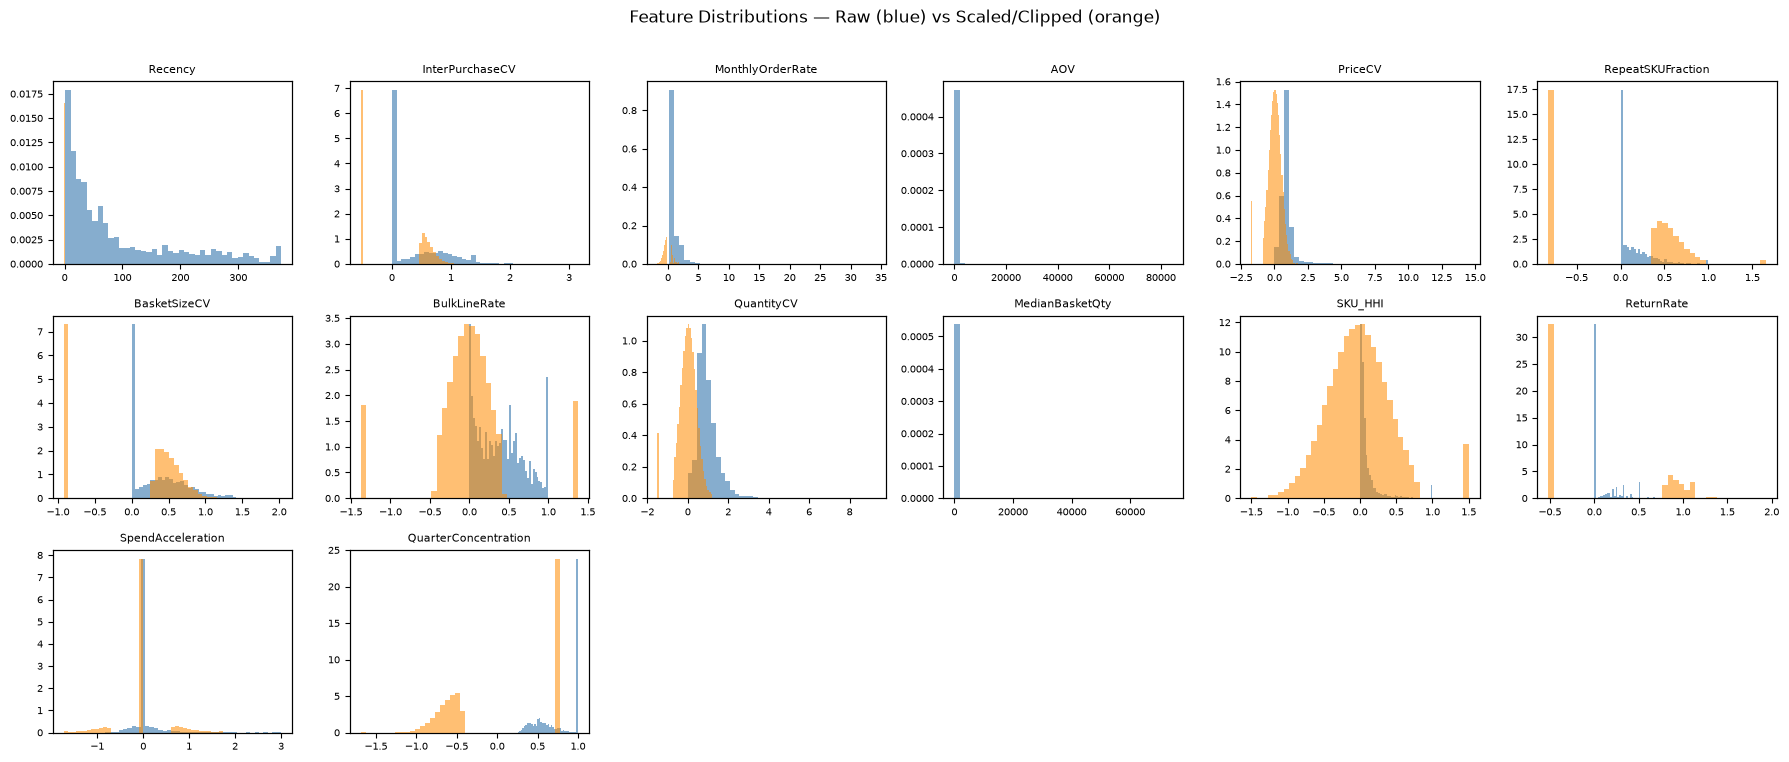

Max |z| after clip: 1.9319325437073487


In [7]:
# Feature distributions: raw vs scaled
feat_cols = fe.feature_customer
n = len(feat_cols)
ncols = 6
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.5))
axes = axes.flatten()

raw_df = customer_features.set_index('CustomerID')[feat_cols]

for i, col in enumerate(feat_cols):
    ax = axes[i]
    ax.hist(raw_df[col], bins=40, color='steelblue', alpha=0.65, label='raw', density=True)
    ax2 = ax.twinx()
    ax2.hist(df_scaled[col], bins=40, color='darkorange', alpha=0.55, label='scaled', density=True)
    ax2.set_yticks([])
    ax.set_title(col, fontsize=8)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions — Raw (blue) vs Scaled/Clipped (orange)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../figures/02_features/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print("Max |z| after clip:", df_scaled.abs().max().max())

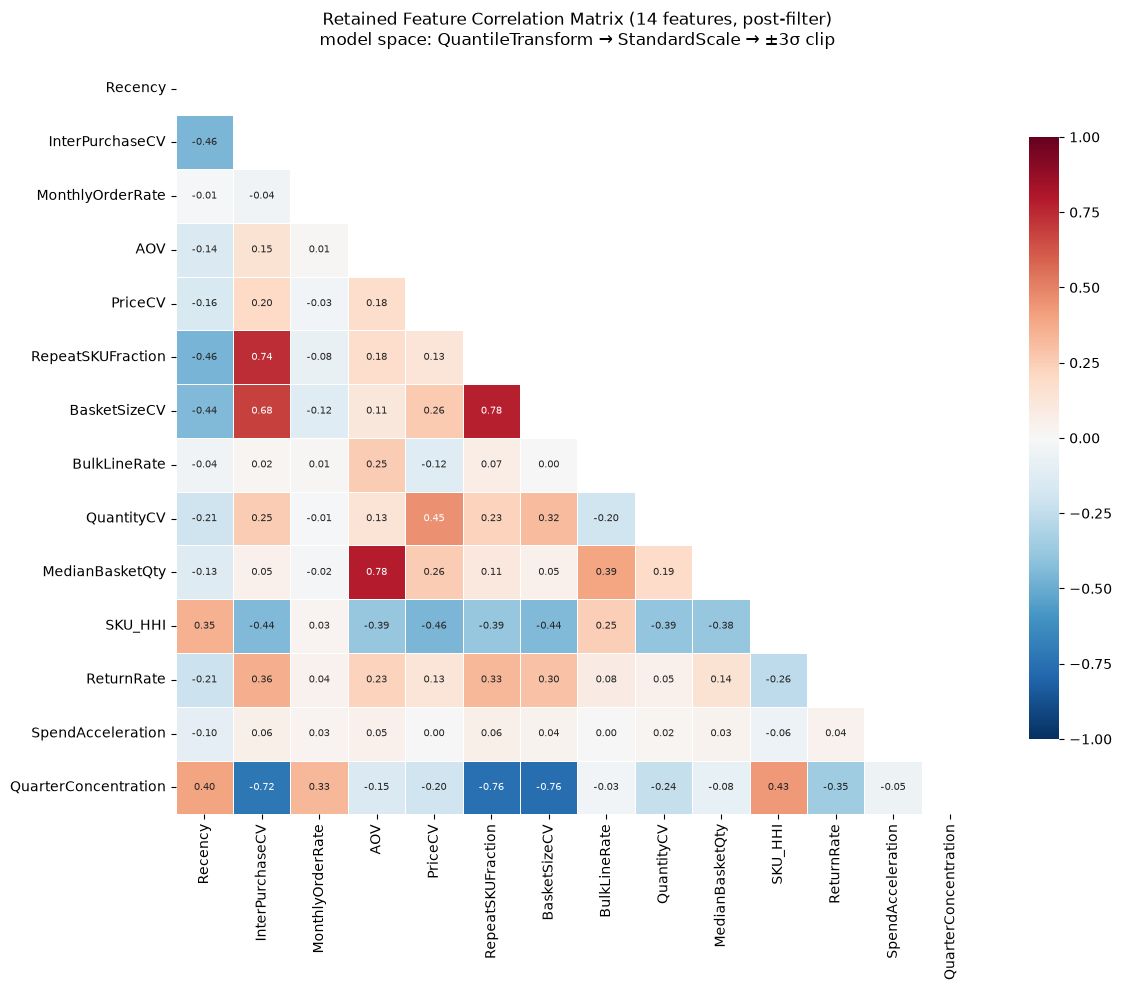

Max off-diagonal |r| in model space (post-filter): 0.781  (filter threshold was 0.85)


In [8]:
# Correlation matrix of retained features in the MODEL SPACE
# (QuantileTransform → StandardScale → ±3σ clip) — the same space the greedy
# Pearson filter ran in.  Raw-space correlations are NOT comparable to the 0.85
# threshold and will over-state collinearity for heavy-tailed features.
corr = df_scaled.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 7}
)
ax.set_title(
    "Retained Feature Correlation Matrix (14 features, post-filter)\n"
    "model space: QuantileTransform → StandardScale → ±3σ clip",
    fontsize=12, pad=12,
)
plt.tight_layout()
plt.savefig('../figures/02_features/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

max_offdiag = corr.where(~np.eye(len(corr), dtype=bool)).abs().max().max()
print(f"Max off-diagonal |r| in model space (post-filter): {max_offdiag:.3f}  (filter threshold was 0.85)")
assert max_offdiag <= 0.85, (
    f"Filter invariant violated: max |r| = {max_offdiag:.3f} > 0.85. "
    "Check _filter_by_correlation in features.py."
)

## 5. B2B Identification & Wholesale Isolation

Wholesale-like accounts represent corporate buyers purchasing large quantities focused on single product lines. These accounts create severe noise in retail population clustering due to two core factors:

1. **Geometric Outlier Feature Values:** Perfect revenue concentration (`SKU_HHI` $= 1.0$, entire spend dedicated to one SKU), high bulk order rate (`BulkLineRate` $> 0.9$), and negligible volume variance (`QuantityCV` $\approx 0$). Even following $\pm 3\sigma$ clipping, these remain geometric spatial outliers in $d=14$ feature space.
2. **Divergent Commercial Strategy:** B2B accounts require dedicated account management, volume discount tiers, and contractual pricing — fundamentally distinct from any retail customer segment.

### Why Rule-Based Filtering Over K-Means?
K-Means minimizes global variance across all 14 dimensions simultaneously. Because B2B accounts represent a small subpopulation (**4.6%** of total customers), their signal is concentrated in only 1–2 specific features (`SKU_HHI`, `BulkLineRate`). The primary variance structure across the overall dataset is dominated by retail purchasing patterns (e.g., "Occasional vs. Frequent" shoppers). 

Applying a deterministic rule (`SKU_HHI > 0.5`) isolates wholesale accounts deterministically while maintaining **100% commercial interpretability**.

Total customers  : 3,920
B2B (SKU_HHI > 0.5) : 179  (4.6%)
Retail cohort    : 3,741  (95.4%)


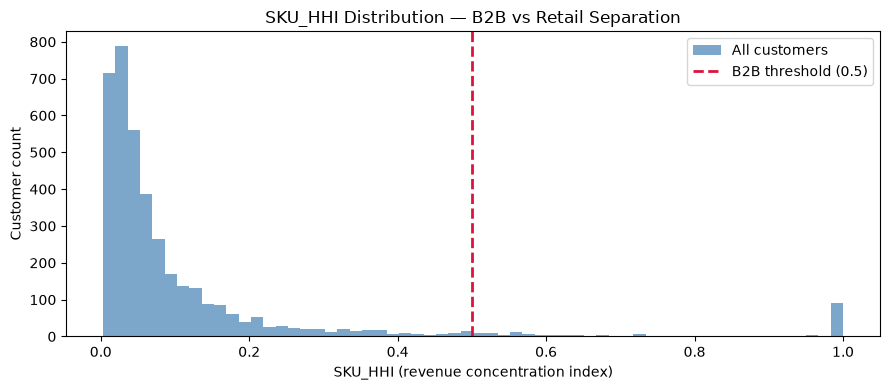

In [9]:
# Apply B2B filter on raw (unscaled) SKU_HHI
raw_df = customer_features.set_index('CustomerID')
B2B_THRESHOLD = 0.5

b2b_mask   = raw_df['SKU_HHI'] > B2B_THRESHOLD
b2b_ids    = raw_df[b2b_mask].index
retail_ids = raw_df[~b2b_mask].index

print(f"Total customers  : {len(raw_df):,}")
print(f"B2B (SKU_HHI > {B2B_THRESHOLD}) : {len(b2b_ids):,}  ({100*len(b2b_ids)/len(raw_df):.1f}%)")
print(f"Retail cohort    : {len(retail_ids):,}  ({100*len(retail_ids)/len(raw_df):.1f}%)")

# Visualise SKU_HHI distribution with threshold
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(raw_df['SKU_HHI'], bins=60, color='steelblue', alpha=0.7, label='All customers')
ax.axvline(B2B_THRESHOLD, color='crimson', lw=2, ls='--', label=f'B2B threshold ({B2B_THRESHOLD})')
ax.set_xlabel('SKU_HHI (revenue concentration index)')
ax.set_ylabel('Customer count')
ax.set_title('SKU_HHI Distribution — B2B vs Retail Separation')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/02_features/b2b_skuhhi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
b2b_profile   = raw_df.loc[b2b_ids].median()
retail_profile = raw_df.loc[retail_ids].median()
comparison = pd.DataFrame({'B2B median': b2b_profile, 'Retail median': retail_profile})
comparison['ratio'] = (comparison['B2B median'] / comparison['Retail median'].replace(0, np.nan)).round(2)
print("B2B vs Retail feature medians (raw):")
print(comparison.sort_values('ratio', ascending=False).to_string())

B2B vs Retail feature medians (raw):
                      B2B median  Retail median  ratio
SKU_HHI                 1.000000       0.046904  21.32
Recency               146.000000      47.000000   3.11
BulkLineRate            1.000000       0.370079   2.70
QuarterConcentration    1.000000       0.727057   1.38
MonthlyOrderRate        1.000000       1.000000   1.00
AOV                   166.316667     286.716667   0.58
QuantityCV              0.336718       0.869170   0.39
MedianBasketQty        52.000000     150.000000   0.35
PriceCV                 0.062027       0.871132   0.07
BasketSizeCV            0.000000       0.309891   0.00
RepeatSKUFraction       0.000000       0.063830   0.00
InterPurchaseCV         0.000000       0.000000    NaN
ReturnRate              0.000000       0.000000    NaN
SpendAcceleration       0.000000       0.000000    NaN


## 6. Save Results

In [11]:
# Lưu artefacts vào sandbox (data/_sandbox/). wpath() tự tạo thư mục nếu chưa có.
scaled_path        = wpath('processed/customer_features_scaled.csv')
retail_scaled_path = wpath('processed/customer_features_retail_scaled.csv')
b2b_ids_path       = wpath('processed/b2b_customer_ids.csv')
models_dir         = wpath('models')

# Full population scaled features (3,920 customers, 14 features)
df_scaled.to_csv(scaled_path)

# Retail cohort scaled features (3,741 customers)
df_retail_scaled = df_scaled.loc[retail_ids]
df_retail_scaled.to_csv(retail_scaled_path)

# B2B customer IDs
pd.Series(b2b_ids, name='CustomerID').to_csv(b2b_ids_path, index=False)

# Save pipeline artefacts (quantile_transformer.pkl, scaler.pkl, pipeline_metadata.json)
fe.save_pipeline(models_dir)

print("Saved:")
print(f"  {scaled_path}        — {df_scaled.shape}")
print(f"  {retail_scaled_path} — {df_retail_scaled.shape}")
print(f"  {b2b_ids_path}       — {len(b2b_ids)} rows")
print(f"  {models_dir}/  — quantile_transformer.pkl, scaler.pkl, pipeline_metadata.json")

Saved:
  C:\Users\Hung Thinh PC\OneDrive\Documents\AIO 2026\Project2.2\customer_segmentation_ai_vietnam\data\_sandbox\processed\customer_features_scaled.csv        — (3920, 14)
  C:\Users\Hung Thinh PC\OneDrive\Documents\AIO 2026\Project2.2\customer_segmentation_ai_vietnam\data\_sandbox\processed\customer_features_retail_scaled.csv — (3741, 14)
  C:\Users\Hung Thinh PC\OneDrive\Documents\AIO 2026\Project2.2\customer_segmentation_ai_vietnam\data\_sandbox\processed\b2b_customer_ids.csv       — 179 rows
  C:\Users\Hung Thinh PC\OneDrive\Documents\AIO 2026\Project2.2\customer_segmentation_ai_vietnam\data\_sandbox\models/  — quantile_transformer.pkl, scaler.pkl, pipeline_metadata.json


## 6. Summary & Data Persistence

### Feature Pipeline Execution Summary

| Metric / Pipeline Stage | Value |
| :--- | :--- |
| **Raw Transactions Processed** | $\approx 397,884$ |
| **Total Unique Customers** | $3,920$ |
| **Candidate Features Engineered** | $20$ (across 5 domains) |
| **Retained Non-Redundant Features** | $14$ (post Pearson correlation pruning, $|r| \le 0.85$) |
| **Preprocessing & Scaling** | `QuantileTransformer(normal, 500q)` $\rightarrow$ `StandardScaler` $\rightarrow$ $\pm 3\sigma$ Clipping |
| **Wholesale / B2B Accounts (`SKU_HHI > 0.5`)** | $179$ ($4.6\%$) |
| **Core Retail Population** | $3,741$ ($95.4\%$) |

---

### Exported Artifacts

* `data/processed/customer_features_scaled.csv`: Matrix of size $3,920 \times 14$ containing scaled features for the full customer base.
* `data/processed/customer_features_retail_scaled.csv`: Matrix of size $3,741 \times 14$ isolating the core retail cohort for K-Means++ clustering.
* `data/processed/b2b_customer_ids.csv`: Identifier list for isolated B2B/wholesale accounts.